In [1]:
from script import run_superfv_sim, run_spd_sim
from superfv import RiemannSolver
import matplotlib.pyplot as plt

In [2]:
sim1 = run_superfv_sim("llf",  3, 768, rtol=1e-5, riemann_solver=RiemannSolver.LLF)
sim2 = run_superfv_sim("hllc", 3, 768, rtol=1e-5, riemann_solver=RiemannSolver.HLLC)
sim3 = run_superfv_sim("llf",  7, 768, rtol=1e-5, riemann_solver=RiemannSolver.LLF)
sim4 = run_superfv_sim("hllc", 7, 768, rtol=1e-5, riemann_solver=RiemannSolver.HLLC)
sim5 = run_spd_sim("llf",  3, 768, tolerance=1e-5, riemann_solver_sd="llf",  riemann_solver_fv="llf")
sim6 = run_spd_sim("hllc", 3, 768, tolerance=1e-5, riemann_solver_sd="hllc", riemann_solver_fv="hllc")
sim7 = run_spd_sim("llf",  7, 768, tolerance=1e-5, riemann_solver_sd="llf",  riemann_solver_fv="llf")
sim8 = run_spd_sim("hllc", 7, 768, tolerance=1e-5, riemann_solver_sd="hllc", riemann_solver_fv="hllc")
sim9 = run_spd_sim("llf_romain_NAD",  3, 768, tolerance=1e-6, riemann_solver_sd="llf",  riemann_solver_fv="llf")
sim10 = run_spd_sim("hllc_romain_NAD", 3, 768, tolerance=1e-6, riemann_solver_sd="hllc", riemann_solver_fv="hllc")
sim11 = run_spd_sim("llf_romain_NAD",  7, 768, tolerance=1e-6, riemann_solver_sd="llf",  riemann_solver_fv="llf")
sim12 = run_spd_sim("hllc_romain_NAD", 7, 768, tolerance=1e-6, riemann_solver_sd="hllc", riemann_solver_fv="hllc")

Error occurred while unpickling /scratch/gpfs/jp7427/FVvsSD/rti/FV_llf_P0=1.0_NDOF=768_p=3/params.pkl: Can't get attribute 'gravity' on <module '__main__'>
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_llf_P0=1.0_NDOF=768_p=3'
Error occurred while unpickling /scratch/gpfs/jp7427/FVvsSD/rti/FV_hllc_P0=1.0_NDOF=768_p=3/params.pkl: Can't get attribute 'gravity' on <module '__main__'>


/home/jp7427/Desktop/FVvsSD/superfv/superfv/mesh.py:268: UserWarning: Cupy is not available. Falling back to NumPy.
  warnings.warn("Cupy is not available. Falling back to NumPy.")


Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_hllc_P0=1.0_NDOF=768_p=3'
Error occurred while unpickling /scratch/gpfs/jp7427/FVvsSD/rti/FV_llf_P0=1.0_NDOF=768_p=7/params.pkl: Can't get attribute 'gravity' on <module '__main__'>
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_llf_P0=1.0_NDOF=768_p=7'
Error occurred while unpickling /scratch/gpfs/jp7427/FVvsSD/rti/FV_hllc_P0=1.0_NDOF=768_p=7/params.pkl: Can't get attribute 'gravity' on <module '__main__'>
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_hllc_P0=1.0_NDOF=768_p=7'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_llf_P0=1.0_NDOF=768_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_hllc_P0=1.0_NDOF=768_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_llf_P0=1.0_NDOF=768_p=7'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_hllc_P0=1.0_NDOF=768_p=7'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_llf_romain_NAD_P0=1.0_NDOF=768_p=3'
Loaded output from '/scratch/gpf

In [3]:
def plot_fv(ax, sim):
    ax.set_aspect("equal")

    x_fv, y_fv, _ = sim.mesh.faces
    z_fv = sim.snapshot_history[-1].w[0, :, :, 0].T
    return ax.pcolormesh(x_fv, y_fv, z_fv)


def plot_sd(ax, sim):
    ax.set_aspect("equal")

    x_sd = sim.regular_faces()[0]
    y_sd = sim.regular_faces()[1]
    z_sd = sim.transpose_to_fv(sim.regular_mesh(sim.dm.W_cv))[0]
    return ax.pcolormesh(x_sd, y_sd, z_sd)

-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_llf_P0=1.0_NDOF=768_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_hllc_P0=1.0_NDOF=768_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_llf_P0=1.0_NDOF=768_p=7/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_hllc_P0=1.0_NDOF=768_p=7/output_000001.pkl.


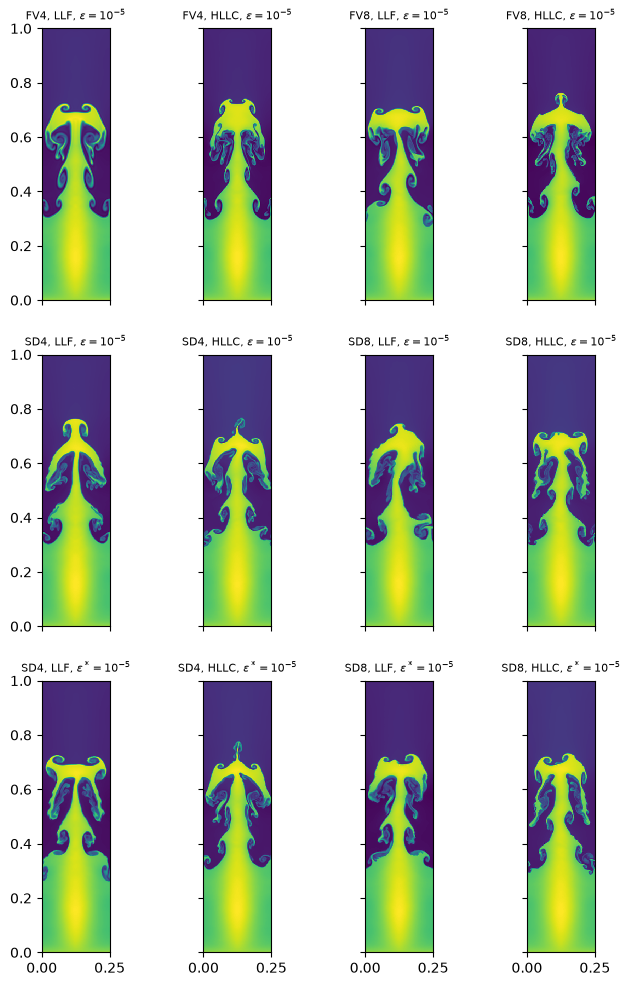

In [4]:
fig, axs = plt.subplots(3, 4, sharex=True, sharey=True, figsize=(8,12))
fontsize=8

axs[0,0].set_title(r"FV4, LLF, $\varepsilon=10^{-5}$", fontsize=fontsize)
plot_fv(axs[0,0], sim1)

axs[0,1].set_title(r"FV4, HLLC, $\varepsilon=10^{-5}$", fontsize=fontsize)
plot_fv(axs[0,1], sim2)

axs[0,2].set_title(r"FV8, LLF, $\varepsilon=10^{-5}$", fontsize=fontsize)
plot_fv(axs[0,2], sim3)

axs[0,3].set_title(r"FV8, HLLC, $\varepsilon=10^{-5}$", fontsize=fontsize)
plot_fv(axs[0,3], sim4)

axs[1,0].set_title(r"SD4, LLF, $\varepsilon=10^{-5}$", fontsize=fontsize)
plot_sd(axs[1,0], sim5)

axs[1,1].set_title(r"SD4, HLLC, $\varepsilon=10^{-5}$", fontsize=fontsize)
plot_sd(axs[1,1], sim6)

axs[1,2].set_title(r"SD8, LLF, $\varepsilon=10^{-5}$", fontsize=fontsize)
plot_sd(axs[1,2], sim7)

axs[1,3].set_title(r"SD8, HLLC, $\varepsilon=10^{-5}$", fontsize=fontsize)
plot_sd(axs[1,3], sim8)

axs[2,0].set_title(r"SD4, LLF, $\varepsilon^*=10^{-5}$", fontsize=fontsize)
plot_sd(axs[2,0], sim9)

axs[2,1].set_title(r"SD4, HLLC, $\varepsilon^*=10^{-5}$", fontsize=fontsize)
plot_sd(axs[2,1], sim10)

axs[2,2].set_title(r"SD8, LLF, $\varepsilon^*=10^{-5}$", fontsize=fontsize)
plot_sd(axs[2,2], sim11)

axs[2,3].set_title(r"SD8, HLLC, $\varepsilon^*=10^{-5}$", fontsize=fontsize)
plot_sd(axs[2,3], sim12)

fig.savefig("rti.png", dpi=300, bbox_inches="tight")